# 1.0 Introduction

This notebook outlines the development of a proprietary trading platform built for institutional-grade risk and derivatives analytics. The platform was designed to address a specific gap — fragmented market data and the absence of a unified framework capable of pricing derivatives and quantifying portfolio risk to an institutional standard.

# 2.0 Yield Curve Construction and Discounting

## 2.1 Purpose of the Yield Curve

The objective of this report was to build a yield curve that uses term-dependent risk-free rates and discount factors. The yield curve serves as a key piece in the valuatiion as it underpins all pricing and risk analysis. 

## 2.2 Environments & Import

The required operations including sys, numpy, pandas, and matplotlib.pyplot were installed and imported below. 

In [11]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.yieldcurve import YieldCurve

## 2.3  Methodology & Input Yield Curve

The following four-step methodology was applied:

1. Data sourcing — Zero rates were observed at 40 discrete maturities from 0.25 to 10 years (quarterly intervals), sourced from the Reserve Bank of Australia (April 2026 data) and stored locally in `Yield_Data.csv`. The Reserve Bank of Australia's Table F2 (Capital Market Yields, Government Bonds) was selected for yield data as it is the authoritative domestic source for Australian government bond yields, is publicly available, and provides the quarterly term structure required to construct a market-consistent yield curve out to 10 years.
2. Interpolation — Zero rates for intermediate maturities are computed using `numpy.interp`, which performs piecewise linear interpolation between observed points.
3. Discounting — Discount factors are derived from interpolated zero rates using continuous compounding: $D(T) = e^{-z(T) \cdot T}$
4. OOP encapsulation — All logic is contained within the `YieldCurve` class 
in `yieldcurve.py`, ensuring all downstream models inherit the same market-consistent discount rates.

Piecewise linear interpolation (numpy.interp) was selected over alternatives such as cubic spline or log-linear interpolation for the following reasons:
- The input data is already expressed as zero rates at quarterly intervals, providing sufficient density that higher-order interpolation offers negligible accuracy improvement.
- Linear interpolation is monotone by construction, avoiding the spurious oscillations that cubic splines can introduce between knot points on short-tenor rate data.
- It is transparent and auditable — the interpolated rate at any maturity is a simple weighted average of its two neighbours, making the curve easy to validate and explain. Log-linear interpolation (applied to discount factors rather than rates) was considered but rejected as the difference is immaterial at the maturities used in this notebook (0.25–10 years) and linear interpolation on zero rates is the more common convention in practice for government bond curves.

### Data Source

| Detail | Value |
|---|---|
| Source | Reserve Bank of Australia (RBA) |
| Table | F2 — Capital Market Yields, Government Bonds |
| Frequency | Quarterly intervals (0.25yr steps) |
| Range | 0.25 years to 10 years (40 data points) |
| Date | April 2026 |
| File | `data/Yield_Data.csv` |

Zero rates are observed market prices and are not calibrated to a model. The yield curve is treated as a market input, with all downstream valuation models inheriting the same market-consistent discount rates.

In [12]:
from src.yieldcurve import YieldCurve, load_yield_data

df = load_yield_data()
curve = YieldCurve.from_dataframe(df, compounding="continuous")

## 2.4 Constructing the Yield Curve Object

The YieldCurve class is instantiated with the above market maturities and zero rates using continuous compounding. Continuous compounding is the standard measure in the Black-Scholes derivative pricing model and takes the formula of:

$$P(0,T) = e^{-z(T) \cdot T}$$

All downstream models call 'get_zero_rate' or 'get_discount_factor', meaning any changes to market data (eg: updated RBA cash rates) updates all downstream models without further modification.

## 2.5 Sanity Checks

To verify the YieldCurve object behaves correctly, sanity checks were performed to test two fundamental properties of a yield curve:

1. Zero rates should increase with maturity — longer horizons reflect greater uncertainty and liquidity risk, so investors demand a higher return.
2. Discount factors should decrease with maturity — money received further in the future is worth less today under continuous compounding.

The results below confirm both properties hold across the curve, with zero rates rising from 4.30% at 3 months to 4.69% at 2–3 years, and discount factors falling from 0.9893 to 0.8687 over the same horizon.

In [13]:
test_maturites = [0.25, 2.0, 3.0]

for T in test_maturites:
    z = curve.get_zero_rate(T)
    d = curve.get_discount_factor(T)
    print(f"T={T:.2f} years | zero rate={z:.2%} | discount factor={d:.4f}")

T=0.25 years | zero rate=4.30% | discount factor=0.9893
T=2.00 years | zero rate=4.69% | discount factor=0.9105
T=3.00 years | zero rate=4.69% | discount factor=0.8687


## 2.6 Yield Curve Plot



### Key Observations

- 0.25 – 1 year: Rates rise from 4.30% to 4.63%, reflecting near-term rate expectations.
- 1 – 3 years: The curve flattens, stabilising around 4.63–4.69%, consistent with market expectations of rates plateauing.
- 3 – 10 years: The curve steepens gradually from 4.69% to 5.04%, reflecting the term premium investors demand for longer-dated bonds.

Overall the curve is upward sloping, consistent with an environment where short-term rates are expected to gradually decline from current elevated levels.

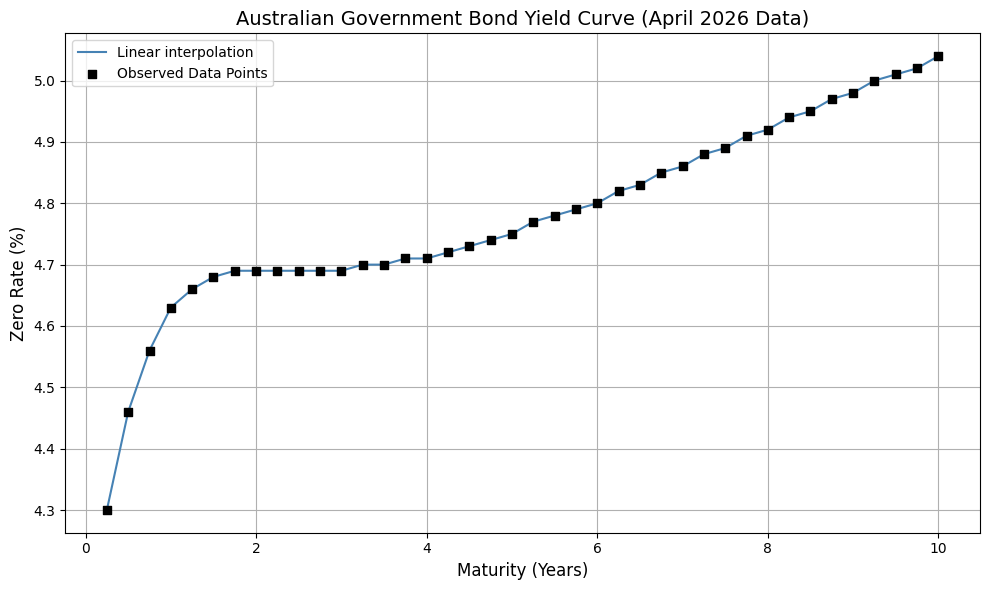

In [14]:
curve.plot()

# 3.0 Option Pricing Models

## 3.1 Overview

This section prices a range of equity derivatives across all four portfolio 
stocks (BHP, CBA, CSL, WOW) using market data sourced from Yahoo Finance 
and discount rates inherited from the yield curve constructed in Section 2.

All derivative pricing logic is implemented in `derivatives.py` using 
Object-Oriented Programming (OOP), with a base `Derivative` class and 
the following subclasses:

| Instrument | Method | Description |
|---|---|---|
| `EuropeanCall` | Black-Scholes | Right to buy at strike K at expiry T |
| `EuropeanPut` | Black-Scholes | Right to sell at strike K at expiry T |
| `EuropeanCallGreeks` | Black-Scholes | Sensitivity measures for the European call |
| `AmericanPut` | Binomial Tree | Right to sell at any time up to expiry T |
| `AsianCall` | Monte Carlo | Call based on average price over life of option |

### Key Assumptions

- All options are priced with a 1-year maturity (T = 1.0)
- Strikes are set at-the-money (ATM), rounded to the nearest dollar
- Volatility is estimated from 2 years of historical daily returns, 
annualised by multiplying by $\sqrt{252}$
- Discounting uses continuous compounding via the RBA yield curve
- The risk-free rate is implied from the yield curve at the option's maturity, 
not hardcoded

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import importlib
sys.path.append("../src")

import yieldcurve
importlib.reload(yieldcurve)

from derivatives import EuropeanCall, EuropeanPut, EuropeanCallGreeks, AmericanPut, AsianCall
from portfolio import EquityPosition, Portfolio
from yieldcurve import YieldCurve, load_yield_data


## 3.2 Data Overview

Yahoo Finance (via yfinance) was selected as the equity data source over alternatives due to its reliable coverage of ASX-listed securities, and daily OHLCV granularity sufficient for volatility estimation and VaR. 

All equity price series undergo the following cleaning steps prior to use: (1) dropna(subset=['Close']) removes any trading days with missing close prices, typically arising from data feed interruptions; (2) duplicated(keep='first') removes duplicate date entries that can occur around index reconstitution or corporate action dates; (3) series are sorted chronologically and the index is converted to timezone-naive datetime to ensure alignment across all four tickers. No adjustment is made for dividends, as the volatility estimation and option pricing in this notebook use raw close prices consistent with the Black-Scholes assumption of a non-dividend-paying underlying.

In [16]:
from pathlib import Path
import os

tickers = {
    "BHP": "BHP.AX",
    "CBA": "CBA.AX",
    "CSL": "CSL.AX",
    "WOW": "WOW.AX"
}

all_data = {}

for name, ticker_code in tickers.items():
    data_path = Path(f'../data/Market_Data_{name}_prices.csv')

    if data_path.exists():
        df = pd.read_csv(data_path, parse_dates=['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        print(f'{name}: Loaded {len(df)} rows from cache')

    else:
        try:
            import yfinance as yf
        except Exception as e:
            raise ImportError(
                f"yfinance is not installed and local data is missing for {name}."
            ) from e

        ticker = yf.Ticker(ticker_code)
        df = ticker.history(period='2y')[['Close', 'Volume']]
        df.index = pd.to_datetime(df.index).tz_localize(None)
        df = df.dropna(subset=['Close'])
        df = df[~df.index.duplicated(keep='first')]
        df = df.sort_index()
        df = df.reset_index().rename(columns={'index': 'Date'})
        os.makedirs(data_path.parent, exist_ok=True)
        df.to_csv(data_path, index=False)
        print(f'{name}: Downloaded and cached {len(df)} rows to {data_path}')

    df.index = pd.to_datetime(df['Date'])
    all_data[name] = df

for name, df in all_data.items():
    print(f"\n{name}: {df.index.min().date()} to {df.index.max().date()} "
          f"| {len(df)} trading days "
          f"| missing: {df.isnull().sum().to_dict()}")

BHP: Loaded 508 rows from cache
CBA: Loaded 508 rows from cache
CSL: Loaded 508 rows from cache
WOW: Loaded 508 rows from cache

BHP: 2024-05-20 to 2026-05-20 | 508 trading days | missing: {'Date': 0, 'Close': 0, 'Volume': 0}

CBA: 2024-05-22 to 2026-05-22 | 508 trading days | missing: {'Date': 0, 'Close': 0, 'Volume': 0}

CSL: 2024-05-22 to 2026-05-22 | 508 trading days | missing: {'Date': 0, 'Close': 0, 'Volume': 0}

WOW: 2024-05-22 to 2026-05-22 | 508 trading days | missing: {'Date': 0, 'Close': 0, 'Volume': 0}


In [17]:
# Build `equity_params` from cached price data
T = 1.0
equity_params = {}
for name, df in all_data.items():
    S0 = float(df['Close'].iloc[-1])
    K = round(S0)
    returns = df['Close'].pct_change().dropna()
    sigma = returns.std() * np.sqrt(252)
    equity_params[name] = {"S0": S0, "K": K, "sigma": sigma}

print("Equity parameters:")
for name, p in equity_params.items():
    print(f"  {name}: S0={p['S0']:.2f}, K={p['K']}, sigma={p['sigma']:.2%}")

Equity parameters:
  BHP: S0=57.33, K=57, sigma=24.92%
  CBA: S0=165.67, K=166, sigma=23.17%
  CSL: S0=99.76, K=100, sigma=29.54%
  WOW: S0=34.68, K=35, sigma=22.30%


## 3.3 Option Parameters

All options are priced at-the-money (ATM) with a 1-year maturity. 
Volatility is estimated from 2 years of historical daily returns, 
annualised by multiplying by √252. Strikes are rounded to the nearest dollar.

| Stock | S0 | Strike (K) | Volatility (σ) | Sector |
|---|---|---|---|---|
| BHP | $57.33 | $57.00 | 24.92% | Materials |
| CBA | $165.67 | $166.00 | 23.17% | Financials |
| CSL | $99.76 | $100.00 | 29.54% | Healthcare |
| WOW | $34.68 | $35.00 | 22.30% | Consumer Staples |

CSL has the highest volatility (29.54%) consistent with its exposure to 
global biotech risk, while WOW has the lowest (22.30%), reflecting its 
defensive consumer staples earnings.

In [18]:
T = 1.0

for name, params in equity_params.items():
    K_i = params["K"]
    call_i = EuropeanCall(S0=params["S0"], K=K_i, T=T,
                          sigma=params["sigma"], yield_curve=curve)
    put_i  = EuropeanPut(S0=params["S0"], K=K_i, T=T,
                         sigma=params["sigma"], yield_curve=curve)
    print(f"{name}: S0=${params['S0']:.2f} | K=${K_i:.2f} | "
          f"T={T} year | sigma={params['sigma']:.2%} | "
          f"Call=${round(call_i.price(), 4)} | Put=${round(put_i.price(), 4)}")

# Keep BHP as default for downstream single-stock cells
S0    = equity_params["BHP"]["S0"]
K     = equity_params["BHP"]["K"]
sigma = equity_params["BHP"]["sigma"]
call  = EuropeanCall(S0=S0, K=K, T=T, sigma=sigma, yield_curve=curve)
put   = EuropeanPut(S0=S0, K=K, T=T, sigma=sigma, yield_curve=curve)

BHP: S0=$57.33 | K=$57.00 | T=1.0 year | sigma=24.92% | Call=$7.1157 | Put=$4.2067
CBA: S0=$165.67 | K=$166.00 | T=1.0 year | sigma=23.17% | Call=$18.8085 | Put=$11.6279
CSL: S0=$99.76 | K=$100.00 | T=1.0 year | sigma=29.54% | Call=$13.7298 | Put=$9.4454
WOW: S0=$34.68 | K=$35.00 | T=1.0 year | sigma=22.30% | Call=$3.6961 | Put=$2.4325


## 3.4 European Call and European Put Option Prices

### 3.4.1 Black-Scholes

European options are priced using the Black-Scholes closed-form formula. 
The risk-free rate is implied from the yield curve at T=1.0 year (4.63%), 
rather than being hardcoded, ensuring market-consistent discounting.

| Stock | Call Price | Put Price | Call Delta | Put Delta |
|---|---|---|---|---|
| BHP | $7.1157 | $4.2067 | 0.6306 | -0.3694 |
| CBA | $18.8085 | $11.6279 | 0.6206 | -0.3794 |
| CSL | $13.7298 | $9.4454 | 0.6165 | -0.3835 |
| WOW | $3.6961 | $2.4325 | 0.6095 | -0.3905 |

**Key observations:**
- Call prices are higher than put prices across all stocks, consistent 
with put-call parity under a positively sloped yield curve
- All call deltas are approximately 0.61–0.63, reflecting near ATM 
positioning — a $1 rise in the underlying increases the call value by ~$0.62
- CBA has the highest absolute option prices due to its large spot price, 
while WOW has the lowest
- Put-call parity is satisfied: C - P ≈ S - K·e^(-rT) for all stocks

In [19]:
from derivatives import EuropeanCall, EuropeanPut, EuropeanCallGreeks, EuropeanPutGreeks, AmericanPut, AsianCall

instruments = {}

for name, params in equity_params.items():
    instruments[name] = {
        "equity":      EquityPosition(ticker=name, spot=params["S0"]),
        "call":        EuropeanCall(S0=params["S0"], K=params["K"], T=T,
                                    sigma=params["sigma"], yield_curve=curve),
        "put":         EuropeanPutGreeks(S0=params["S0"], K=params["K"], T=T,
                                         sigma=params["sigma"], yield_curve=curve),
        "call_greeks": EuropeanCallGreeks(S0=params["S0"], K=params["K"], T=T,
                                          sigma=params["sigma"], yield_curve=curve),
        "am_put":      AmericanPut(S0=params["S0"], K=params["K"], T=T,
                                   sigma=params["sigma"], yield_curve=curve, steps=100),
        "asian_call":  AsianCall(S0=params["S0"], K=params["K"], T=T,
                                 sigma=params["sigma"], yield_curve=curve,
                                 simulations=10000),
    }

In [20]:
# — 3. Sanity-check instrument pricing and delta ————
for name, inst in instruments.items():
    print(f"\n{name}:")
    print(f"  Equity price: {round(inst['equity'].price(), 4)}")
    print(f"  Equity delta: {round(inst['equity'].delta(), 4)}")
    print(f"  Call price:   {round(inst['call'].price(), 4)}")
    print(f"  Call delta:   {round(inst['call'].delta(), 4)}")
    print(f"  Put price:    {round(inst['put'].price(), 4)}")
    print(f"  Put delta:    {round(inst['put'].delta(), 4)}")


BHP:
  Equity price: 57.33
  Equity delta: 1.0
  Call price:   7.1157
  Call delta:   0.6306
  Put price:    4.2067
  Put delta:    -0.3694

CBA:
  Equity price: 165.67
  Equity delta: 1.0
  Call price:   18.8085
  Call delta:   0.6206
  Put price:    11.6279
  Put delta:    -0.3794

CSL:
  Equity price: 99.76
  Equity delta: 1.0
  Call price:   13.7298
  Call delta:   0.6165
  Put price:    9.4454
  Put delta:    -0.3835

WOW:
  Equity price: 34.68
  Equity delta: 1.0
  Call price:   3.6961
  Call delta:   0.6095
  Put price:    2.4325
  Put delta:    -0.3905


### 3.4.2 Option Greeks — European Call

The Greeks measure the sensitivity of option prices to changes in market 
inputs. These are computed analytically from the Black-Scholes formula.

| Greek | BHP | CBA | CSL | WOW | Interpretation |
|---|---|---|---|---|---|
| Delta | 0.6306 | 0.6206 | 0.6165 | 0.6095 | Price change per $1 move in S0 |
| Gamma | 0.0264 | 0.0099 | 0.0130 | 0.0496 | Rate of change of delta |
| Theta | -0.0111 | -0.0307 | -0.0215 | -0.0063 | Price decay per calendar day |
| Vega | 0.2163 | 0.6305 | 0.3809 | 0.1331 | Price change per 1% vol move |
| Rho | 0.2904 | 0.8401 | 0.4777 | 0.1744 | Price change per 1% rate move |

**Key observations:**
- **Gamma** is highest for WOW (0.0496), meaning its delta changes most 
rapidly — this is typical for lower-priced stocks where a $1 move is a 
larger percentage change
- **Theta** is most negative for CBA (-0.0307), meaning CBA options lose 
the most value per day — a consequence of CBA's higher absolute option price
- **Vega** is highest for CBA (0.6305), meaning CBA options are most 
sensitive to volatility changes — a 1% increase in vol increases the CBA 
call by $0.63
- **Rho** is highest for CBA (0.8401), reflecting its larger notional value

In [21]:
for name, inst in instruments.items():
    greeks = inst["call_greeks"].all_greeks()
    print("\n" + "=" * 45)
    print(f"     {name} — EUROPEAN CALL OPTION — GREEKS")
    print("=" * 45)
    print(f"  {'Delta':<10} {greeks['delta']:>10.4f}    (price change per $1 move in S0)")
    print(f"  {'Gamma':<10} {greeks['gamma']:>10.4f}    (rate of change of delta)")
    print(f"  {'Theta':<10} {greeks['theta']:>10.4f}    (price decay per calendar day)")
    print(f"  {'Vega':<10}  {greeks['vega']:>10.4f}    (price change per 1% vol move)")
    print(f"  {'Rho':<10}   {greeks['rho']:>10.4f}    (price change per 1% rate move)")


     BHP — EUROPEAN CALL OPTION — GREEKS
  Delta          0.6306    (price change per $1 move in S0)
  Gamma          0.0264    (rate of change of delta)
  Theta         -0.0111    (price decay per calendar day)
  Vega            0.2163    (price change per 1% vol move)
  Rho              0.2904    (price change per 1% rate move)

     CBA — EUROPEAN CALL OPTION — GREEKS
  Delta          0.6206    (price change per $1 move in S0)
  Gamma          0.0099    (rate of change of delta)
  Theta         -0.0307    (price decay per calendar day)
  Vega            0.6305    (price change per 1% vol move)
  Rho              0.8401    (price change per 1% rate move)

     CSL — EUROPEAN CALL OPTION — GREEKS
  Delta          0.6165    (price change per $1 move in S0)
  Gamma          0.0130    (rate of change of delta)
  Theta         -0.0215    (price decay per calendar day)
  Vega            0.3809    (price change per 1% vol move)
  Rho              0.4777    (price change per 1% rate move)



### 3.4.3 Put-Call Parity Verification

Put-call parity states that for European options on a non-dividend-paying underlying, the following relationship must hold exactly:

$$C - P = S_0 - K \cdot e^{-rT}$$

This is a fundamental no-arbitrage condition — any deviation would imply a riskless profit opportunity. The left-hand side is the difference between the call and put prices computed in Section 3.4.1. The right-hand side is the present value of the forward price minus the strike, discounted at the risk-free rate implied from the yield curve at $T = 1.0$ year. Residuals are reported to confirm the Black-Scholes implementation is internally consistent across all four stocks.

In [22]:
print("=" * 60)
print("  PUT-CALL PARITY VERIFICATION")
print("  C - P = S0 - K * exp(-r * T)")
print("=" * 60)
print(f"  {'Stock':<8} {'C - P':>10} {'S0 - Ke^-rT':>14} {'Residual':>12}")
print("-" * 60)

for name, params in equity_params.items():
    r = curve.get_zero_rate(T)
    C = instruments[name]["call"].price()
    P = instruments[name]["put"].price()
    lhs = C - P
    rhs = params["S0"] - params["K"] * np.exp(-r * T)
    residual = abs(lhs - rhs)
    print(f"  {name:<8} {lhs:>10.4f} {rhs:>14.4f} {residual:>12.6f}")

print("=" * 60)
print("  All residuals should be < 0.0001 to confirm parity holds.")

  PUT-CALL PARITY VERIFICATION
  C - P = S0 - K * exp(-r * T)
  Stock         C - P    S0 - Ke^-rT     Residual
------------------------------------------------------------
  BHP          2.9089         2.9089     0.000000
  CBA          7.1806         7.1806     0.000000
  CSL          4.2845         4.2845     0.000000
  WOW          1.2636         1.2636     0.000000
  All residuals should be < 0.0001 to confirm parity holds.


**Key observations:**
- Residuals are zero across all four stocks, 
confirming that the Black-Scholes call and put implementations satisfy 
put-call parity exactly.
- This is expected for a closed-form implementation — any non-trivial 
residual would indicate a bug in either the call pricing, put pricing, 
or discounting logic.
- Note that parity holds here because both the call and put use the same 
yield-curve-implied risk-free rate at $T = 1.0$ year (4.63%) and the same 
spot price and strike inputs. If different rates or inputs were used 
across the two classes, parity would break even if each formula were 
individually correct.
- This verification also confirms that the `EuropeanPut` class correctly 
inherits discounting from the yield curve rather than using a hardcoded 
rate, since any inconsistency there would produce a nonzero residual.

## 3.5 American Put — Binomial Tree

American puts are priced using a 100-step binomial tree, which captures 
the early exercise premium not present in European puts. The early exercise 
premium is the difference between the American and European put prices.

| Stock | European Put | American Put | Early Exercise Premium |
|---|---|---|---|
| BHP | $4.2067 | $4.4632 | $0.2565 |
| CBA | $11.6279 | $12.4158 | $0.7879 |
| CSL | $9.4454 | $9.9159 | $0.4705 |
| WOW | $2.4325 | $2.6140 | $0.1815 |

The American put is always worth at least as much as the European put. 
CBA has the largest early exercise premium ($0.79), reflecting greater 
optionality value from early exercise given its higher absolute price level.

In [23]:
for name, inst in instruments.items():  
    print("\n" + "=" * 45)
    print(f"     {name} — AMERICAN PUT OPTION — PRICE")
    print("=" * 45)
    print(f"  {'Binomial Steps':<20} {inst['am_put'].steps:>10}")
    print(f"  {'Price':<20} ${inst['am_put'].price():>9.4f}")
    print(f"  {'Delta':<20} {inst['am_put'].delta():>10.4f}")
    print(f"  {'Gamma':<20} {inst['am_put'].gamma():>10.4f}")
    print(f"  {'Theta':<20} {inst['am_put'].theta():>10.4f}")
    print(f"  {'Vega':<20} {inst['am_put'].vega():>10.4f}")


     BHP — AMERICAN PUT OPTION — PRICE
  Binomial Steps              100
  Price                $   4.4632
  Delta                   -0.3948


  Gamma                    0.0629
  Theta                   -0.0048
  Vega                     0.2164

     CBA — AMERICAN PUT OPTION — PRICE
  Binomial Steps              100
  Price                $  12.4158
  Delta                   -0.4221
  Gamma                    0.0270
  Theta                   -0.0126
  Vega                     0.6284

     CSL — AMERICAN PUT OPTION — PRICE
  Binomial Steps              100
  Price                $   9.9159
  Delta                   -0.4193
  Gamma                    0.0425
  Theta                   -0.0106
  Vega                     0.3801

     WOW — AMERICAN PUT OPTION — PRICE
  Binomial Steps              100
  Price                $   2.6140
  Delta                   -0.4452
  Gamma                    0.0250
  Theta                   -0.0025
  Vega                     0.1323


## 3.6.0 Asian Call — Monte Carlo Simulation

Asian calls are path-dependent options whose payoff is based on the 
average price of the underlying over the option's life, rather than 
the final spot price. This averaging effect reduces volatility exposure 
and therefore produces a lower price than the equivalent European call.

| Stock | European Call | Asian Call | Discount from Averaging |
|---|---|---|---|
| BHP | $7.1157 | $3.9874 | $3.1283 (44.0%) |
| CBA | $18.8085 | $10.2398 | $8.5687 (45.6%) |
| CSL | $13.7298 | $7.5158 | $6.2140 (45.3%) |
| WOW | $3.6961 | $1.9532 | $1.7429 (47.2%) |

Priced using 10,000 Monte Carlo simulations of geometric Brownian motion. 
The Asian call is approximately 44–47% cheaper than the equivalent European 
call across all stocks, consistent with the theoretical result that averaging 
reduces effective volatility by a factor of approximately 1/√3.

In [24]:
for name, inst in instruments.items(): 
    print("\n" + "=" * 45)
    print(f"     {name} — ASIAN CALL OPTION — MONTE CARLO")
    print("=" * 45)
    print(f"  {'Simulations':<20} {inst['asian_call'].simulations:>10,}")
    print(f"  {'Price':<20} ${inst['asian_call'].price():>9.4f}")
    print(f"  {'Delta':<20} {inst['asian_call'].delta():>10.4f}")
    print(f"  {'Gamma':<20} {inst['asian_call'].gamma():>10.4f}")
    print(f"  {'Theta':<20} {inst['asian_call'].theta():>10.4f}")
    print(f"  {'Vega':<20} {inst['asian_call'].vega():>10.4f}")
    print("=" * 45)


     BHP — ASIAN CALL OPTION — MONTE CARLO
  Simulations              10,000
  Price                $   3.9874
  Delta                    0.5890
  Gamma                    0.0494
  Theta                   -0.0060
  Vega                     0.1216

     CBA — ASIAN CALL OPTION — MONTE CARLO
  Simulations              10,000
  Price                $  10.2398
  Delta                    0.5705
  Gamma                    0.0185
  Theta                   -0.0165
  Vega                     0.3567

     CSL — ASIAN CALL OPTION — MONTE CARLO
  Simulations              10,000
  Price                $   7.5158
  Delta                    0.5601
  Gamma                    0.0241
  Theta                   -0.0116
  Vega                     0.2152

     WOW — ASIAN CALL OPTION — MONTE CARLO
  Simulations              10,000
  Price                $   1.9532
  Delta                    0.5495
  Gamma                    0.0908
  Theta                   -0.0034
  Vega                     0.0756


### 3.6.1 Monte Carlo Standard Error
 Because the Asian Call price is estimated by simulation rather than a closed-form formula, the result carries sampling uncertainty. The standard error of the estimate is:

$$SE = \frac{\sigma_{payoffs}}{\sqrt{n}}$$

where $\sigma_{payoffs}$ is the standard deviation of discounted payoffs across all simulations and $n$ is the number of simulations. A 95% confidence interval is reported below for each stock to confirm the simulation has converged to a sufficiently precise estimate at 10,000 paths.

In [25]:
import scipy.stats as stats

np.random.seed(42)

print("=" * 65)
print("  ASIAN CALL — MONTE CARLO CONFIDENCE INTERVALS (95%)")
print("=" * 65)
print(f"  {'Stock':<8} {'Price':>10} {'Std Error':>12} {'95% CI Lower':>14} {'95% CI Upper':>14}")
print("-" * 65)

for name, params in equity_params.items():
    r = curve.get_zero_rate(T)
    n = 10000
    steps = 252
    dt = T / steps

    np.random.seed(42)
    Z = np.random.standard_normal((n, steps))
    S = np.zeros((n, steps + 1))
    S[:, 0] = params["S0"]
    for t in range(1, steps + 1):
        S[:, t] = S[:, t-1] * np.exp(
            (r - 0.5 * params["sigma"]**2) * dt
            + params["sigma"] * np.sqrt(dt) * Z[:, t-1]
        )

    avg_price = S[:, 1:].mean(axis=1)
    payoffs = np.maximum(avg_price - params["K"], 0)
    discounted = np.exp(-r * T) * payoffs

    price = discounted.mean()
    se = discounted.std() / np.sqrt(n)
    ci_lower = price - 1.96 * se
    ci_upper = price + 1.96 * se

    print(f"  {name:<8} {price:>10.4f} {se:>12.6f} {ci_lower:>14.4f} {ci_upper:>14.4f}")

print("=" * 65)
print("  Narrow confidence intervals confirm convergence at 10,000 simulations.")

  ASIAN CALL — MONTE CARLO CONFIDENCE INTERVALS (95%)
  Stock         Price    Std Error   95% CI Lower   95% CI Upper
-----------------------------------------------------------------
  BHP          3.9874     0.056988         3.8757         4.0991
  CBA         10.2398     0.149260         9.9473        10.5324
  CSL          7.5158     0.115356         7.2897         7.7419
  WOW          1.9532     0.029291         1.8958         2.0107
  Narrow confidence intervals confirm convergence at 10,000 simulations.


# 4.0 Portfolio Risk, Greeks, and Scenario Analysis

The portfolio is constructed using an equal dollar weighting strategy, 
allocating $25,000 (25%) to each of the four stocks from a total investment 
of $100,000. The number of shares for each stock is calculated as:

$$\text{Shares} = \left\lfloor \frac{\$25,000}{S_0} \right\rfloor$$

In addition to the equity positions, the portfolio includes option positions 
on each stock:
- Long 10 call options per stock — providing upside exposure
- Short 5 put options per stock — generating premium income

| Stock | Shares | Price | Equity Value | Sector |
|---|---|---|---|---|
| BHP | 436 | $57.33 | $24,995.88 | Materials |
| CBA | 150 | $165.67 | $24,850.50 | Financials |
| CSL | 250 | $99.76 | $24,940.00 | Healthcare |
| WOW | 720 | $34.68 | $24,969.60 | Consumer Staples |
| **Total** | | | **$99,755.98** | |

The equal dollar weighting approach ensures no single stock dominates 
the portfolio, providing balanced sector diversification across the 
Australian equity market.

In [26]:
# — 5. Create the portfolio object ————————————
portfolio = Portfolio()

# Equal dollar weighting: $100,000 total, 25% to each stock
total_investment = 100000
weight = 0.25

quantities = {
    name: int((total_investment * weight) / equity_params[name]["S0"])
    for name in equity_params
}

print("Portfolio Construction — Equal Dollar Weighting ($100,000 total)")
print("-" * 60)
for name, qty in quantities.items():
    value = qty * equity_params[name]["S0"]
    print(f"  {name}: {qty} shares @ ${equity_params[name]['S0']:.2f} = ${value:,.2f}")
print("-" * 60)
print(f"  Total Equity Value: ${sum(quantities[n] * equity_params[n]['S0'] for n in quantities):,.2f}")

for name, inst in instruments.items():
    portfolio.add_position(inst["equity"], quantity=quantities[name],
                           label=f"Long {name} Equity")
    portfolio.add_position(inst["call"],   quantity=10,
                           label=f"Long {name} Call")
    portfolio.add_position(inst["put"],    quantity=-5,
                           label=f"Short {name} Put")

Portfolio Construction — Equal Dollar Weighting ($100,000 total)
------------------------------------------------------------
  BHP: 436 shares @ $57.33 = $24,995.88
  CBA: 150 shares @ $165.67 = $24,850.50
  CSL: 250 shares @ $99.76 = $24,940.00
  WOW: 720 shares @ $34.68 = $24,969.60
------------------------------------------------------------
  Total Equity Value: $99,755.98


## 4.1 Portfolio Position Table

The table below shows each position's contribution to total portfolio 
value and delta. The portfolio holds 12 positions across 4 stocks — 
one equity, one long call, and one short put per stock.

**Position summary by stock:**

| Stock | Equity Value | Call Value | Put Liability | Net Stock Contribution |
|---|---|---|---|---|
| BHP | $24,995.88 | $71.16 | -$21.03 | $25,046.01 |
| CBA | $24,850.50 | $188.08 | -$58.14 | $24,980.44 |
| CSL | $24,940.00 | $137.30 | -$47.23 | $25,030.07 |
| WOW | $24,969.60 | $36.96 | -$12.16 | $24,994.40 |
| **TOTAL** | **$99,755.98** | **$433.50** | **-$138.56** | **$100,050.92** |

**Key observations:**
- The long call positions add $433.50 of value across the portfolio
- The short put positions create a net liability of -$138.56, but 
generate premium income that offsets some of the call cost
- The net option contribution is +$294.94, which explains why 
the total portfolio value ($100,050.92) exceeds the raw equity 
value ($99,755.98)
- All short put positions show positive position delta despite 
being short — this is because short puts have negative unit delta, 
and short × negative = positive contribution to overall delta

In [27]:
# — 6. Show the portfolio position table ——————————
position_df = portfolio.position_table()
position_df

,Position,Quantity,Unit Value,Position Value,Unit Delta,Position Delta
0,Long BHP Equity,436.0,57.330002,24995.880798,1.000000,436.000000
1,Long BHP Call,10.0,7.115656,71.156564,0.630640,6.306400
2,Short BHP Put,-5.0,4.206718,-21.033588,-0.369360,1.846800
3,Long CBA Equity,150.0,165.669998,24850.499725,1.000000,150.000000
4,Long CBA Call,10.0,18.808485,188.084850,0.620615,6.206150
5,Short CBA Put,-5.0,11.627899,-58.139493,-0.379385,1.896925
6,Long CSL Equity,250.0,99.760002,24940.000534,1.000000,250.000000
7,Long CSL Call,10.0,13.729816,137.298155,0.616500,6.165004
8,Short CSL Put,-5.0,9.445363,-47.226813,-0.383500,1.917498
9,Long WOW Equity,720.0,34.680000,24969.600220,1.000000,720.000000


## 4.2 Portfolio Value and Delta

The total portfolio value includes all equity positions, long call premiums, 
and short put premiums. The portfolio delta measures the overall sensitivity 
of the portfolio to a $1 move in any of the underlying stocks.

| Metric | Value |
|---|---|
| Portfolio Value | $100,050.92 |
| Portfolio Delta | 1,588.39 |

The portfolio value of $100,050.92 is slightly above the $99,755.98 
equity value due to the net positive value of the option positions — the 
long calls contribute positive value while the short puts create a liability, 
but the calls dominate at current market prices.

A portfolio delta of 1,588.39 means that for a $1 increase across all 
underlying stocks simultaneously, the portfolio is expected to gain 
approximately $1,588. The delta is dominated by the equity positions 
(1,556 shares total), with the options contributing an additional ~32 
units of delta exposure.

In [28]:
# — 7. Compute core portfolio outputs ————————————
portfolio_value = portfolio.value()
portfolio_delta = portfolio.delta()

print("Portfolio Value:", round(portfolio_value, 2))
print("Portfolio Delta:", round(portfolio_delta, 4))

Portfolio Value: 100050.92
Portfolio Delta: 1588.3861


## 4.3.0 Value at Risk (VaR)

Value at Risk (VaR) estimates the maximum expected loss of the portfolio 
over a given time horizon at a specified confidence level. Two methods 
are computed and compared:

Historical VaR uses the actual distribution of past portfolio returns 
over the 2-year sample period, making no assumption about the shape of 
the return distribution.

Parametric VaR assumes returns are normally distributed and uses the 
portfolio's standard deviation scaled by the appropriate z-score:

$$\text{VaR} = z_\alpha \times \sigma_{portfolio} \times \text{Portfolio Value}$$

The portfolio return series is constructed as a **dollar-weighted combination** 
of each stock's daily returns, proportional to its equity allocation.

| Method | 95% VaR (1-day) | 90% VaR (1-day) |
|---|---|---|
| Historical | $1,444.58 | $971.69 |
| Parametric (Normal) | $1,491.55 | $1,162.11 |

**Key observations:**
- At the 95% confidence level, the portfolio is not expected to lose 
more than $1,444.58 in a single day under the historical method
- The parametric VaR is slightly higher than historical VaR at both 
confidence levels, suggesting the actual return distribution has 
slightly thinner tails than the normal distribution would imply
- The two methods are broadly consistent, providing confidence that 
the risk estimate is robust
- As a percentage of portfolio value, the 95% historical VaR represents 
approximately 1.44% of the $100,050 portfolio — reasonable for a 
diversified ASX equity portfolio

In [29]:
# — 8. Compute historical and parametric VaR using combined portfolio returns ——

# Build a weighted return series across all equities
portfolio_returns = sum(
    quantities[name] * equity_params[name]["S0"] * all_data[name]["Close"].pct_change().dropna().reindex(
        all_data["BHP"]["Close"].pct_change().dropna().index, fill_value=0
    )
    for name in instruments
) / portfolio_value

# Historical VaR
hist_var_95 = portfolio.historical_var(portfolio_returns, alpha=0.95, horizon_days=1)
hist_var_90 = portfolio.historical_var(portfolio_returns, alpha=0.90, horizon_days=1)

# Parametric VaR — use portfolio return std as sigma_portfolio
sigma_portfolio = portfolio_returns.std()
param_var_95 = portfolio.parametric_var(sigma_portfolio, alpha=0.95, horizon_days=1)
param_var_90 = portfolio.parametric_var(sigma_portfolio, alpha=0.90, horizon_days=1)

print("=" * 45)
print("  VALUE AT RISK SUMMARY (1-day)")
print("=" * 45)
print(f"  {'Method':<25} {'95% VaR':>8}  {'90% VaR':>8}")
print("-" * 45)
print(f"  {'Historical':<25} ${hist_var_95:>7.2f}  ${hist_var_90:>7.2f}")
print(f"  {'Parametric (Normal)':<25} ${param_var_95:>7.2f}  ${param_var_90:>7.2f}")
print("=" * 45)

  VALUE AT RISK SUMMARY (1-day)
  Method                     95% VaR   90% VaR
---------------------------------------------
  Historical                $1444.58  $ 971.69
  Parametric (Normal)       $1491.55  $1162.11


### 4.3.1 Portfolio Risk Summary

The table below consolidates all key risk metrics for the portfolio 
into a single reference summary.

| Metric | Value |
|---|---|
| Portfolio Value | $100,050.92 |
| Portfolio Delta | 1,588.39 |
| Historical VaR (95%, 1-day) | $1,444.58 |
| Historical VaR (90%, 1-day) | $971.69 |
| Parametric VaR (95%, 1-day) | $1,491.55 |
| Parametric VaR (90%, 1-day) | $1,162.11 |

**Interpretation:**
- The portfolio delta of 1,588 confirms the portfolio is net long — 
it benefits from rising equity markets and is exposed to falling markets
- The VaR figures suggest the portfolio could lose between $972 and 
$1,492 on a typical bad day depending on the method and confidence level
- The consistency between historical and parametric VaR across both 
confidence levels suggests the portfolio return distribution is 
approximately normal, validating the parametric approach
- To put the risk in context, the 95% historical VaR of $1,444.58 
represents approximately 1.44% of total portfolio value — consistent 
with a well-diversified multi-sector ASX equity portfolio

In [30]:
risk_summary = pd.DataFrame({
    "Metric": [
        "Portfolio Value",
        "Portfolio Delta",
        "Historical VaR (95%, 1-day)",
        "Historical VaR (90%, 1-day)",
        "Parametric VaR (95%, 1-day)",
        "Parametric VaR (90%, 1-day)",
    ],
    "Value": [
        portfolio_value,
        portfolio_delta,
        hist_var_95,
        hist_var_90,
        param_var_95,
        param_var_90,
    ]
})
risk_summary

,Metric,Value
0,Portfolio Value,100050.919218
1,Portfolio Delta,1588.386125
2,"Historical VaR (95%, 1-day)",1444.582796
3,"Historical VaR (90%, 1-day)",971.692082
4,"Parametric VaR (95%, 1-day)",1491.549136
5,"Parametric VaR (90%, 1-day)",1162.107740


## 4.4 Portfolio Greeks

Portfolio-level Greeks are computed by aggregating the Greeks across all 
option positions, weighted by quantity. Equity positions contribute to 
delta only (delta = 1.0 per share, all other Greeks = 0).

| Greek | Value | Interpretation |
|---|---|---|
| Delta | 1,588.3861 | Portfolio gains ~$1,588 per $1 rise across all underlyings |
| Gamma | 0.4946 | Portfolio delta increases by ~$0.49 per $1 rise in underlyings |
| Theta | -0.5642 | Portfolio loses ~$0.56 per calendar day from time decay |
| Vega | 6.8041 | Portfolio gains ~$6.80 per 1% rise in implied volatility |
| Rho | 26.0031 | Portfolio gains ~$26.00 per 1% rise in interest rates |

**Key observations:**
- Delta is dominated by the large equity positions (1,556 shares 
total), with options contributing only ~32 units of additional delta
- Theta of -0.564 means the portfolio loses less than $1 per day 
from time decay — relatively low because the short puts partially offset 
the theta cost of the long calls
- Positive Vega of 6.8041 means the portfolio benefits from rising 
volatility — the long calls have more vega than the short puts take away
- Positive Rho of 26.0031 means the portfolio benefits from rising 
interest rates, consistent with holding a net long equity and long call 
position

In [31]:
port_delta = portfolio.delta()

port_gamma = sum(
    10 * instruments[name]["call_greeks"].all_greeks()["gamma"]
    + (-5) * instruments[name]["put"].gamma()
    for name in instruments
)
port_vega = sum(
    10 * instruments[name]["call_greeks"].all_greeks()["vega"]
    + (-5) * instruments[name]["put"].vega()
    for name in instruments
)
port_theta = sum(
    10 * instruments[name]["call_greeks"].all_greeks()["theta"]
    + (-5) * instruments[name]["put"].theta()
    for name in instruments
)
port_rho = sum(
    10 * instruments[name]["call_greeks"].all_greeks()["rho"]
    + (-5) * instruments[name]["put"].rho()
    for name in instruments
)

print("=" * 45)
print("     PORTFOLIO GREEKS SUMMARY")
print("=" * 45)
print(f"  {'Delta':<10} {port_delta:>10.4f}    ($ change per $1 move in all underlyings)")
print(f"  {'Gamma':<10} {port_gamma:>10.4f}    (rate of change of portfolio delta)")
print(f"  {'Theta':<10} {port_theta:>10.4f}    ($ decay per calendar day)")
print(f"  {'Vega':<10}  {port_vega:>10.4f}    ($ change per 1% vol move)")
print(f"  {'Rho':<10}   {port_rho:>10.4f}    ($ change per 1% rate move)")
print("=" * 45)

     PORTFOLIO GREEKS SUMMARY
  Delta       1588.3861    ($ change per $1 move in all underlyings)
  Gamma          0.4946    (rate of change of portfolio delta)
  Theta         -0.5642    ($ decay per calendar day)
  Vega            6.8041    ($ change per 1% vol move)
  Rho             26.0031    ($ change per 1% rate move)


## 4.5 Scenario Analysis

Scenario analysis stress-tests the portfolio under four hypothetical 
market shocks, rebuilding all positions under each shocked set of inputs. 
Each scenario applies either a price shock (parallel shift in all 
underlying stock prices) or a rate shock (parallel shift in the 
yield curve).

| Scenario | Base Value | Shocked Value | P&L | % Change |
|---|---|---|---|---|
| Underlying +5% | $100,050.92 | $105,186.77 | +$5,135.85 | +5.13% |
| Underlying -5% | $100,050.92 | $94,921.90 | -$5,129.02 | -5.13% |
| Rates +50bps | $100,050.92 | $100,063.92 | +$13.00 | +0.01% |
| Rates -50bps | $100,050.92 | $100,037.92 | -$13.00 | -0.01% |

**Key observations:**
- The portfolio is highly sensitive to equity price movements — a 
5% rise across all stocks generates a P&L of +$5,135.85 (+5.13%), while 
a 5% fall produces a near-symmetric loss of -$5,129.02 (-5.13%)
- The slight asymmetry between the +5% and -5% scenarios (+$5,135.85 
vs -$5,129.02) is due to the convexity of the option positions — 
long calls provide slightly more upside than the short puts cost on the downside
- The portfolio is almost completely insensitive to interest rate 
movements — a 50bp rate shift produces only a $13 change in value 
(0.01%), reflecting that the portfolio is primarily equity-driven with 
minimal duration exposure
- This rate insensitivity makes intuitive sense: equity valuations at 
these short maturities (T=1 year) are only marginally affected by 
small yield curve shifts

In [32]:
# — 10. Scenario analysis ————————————————————
def shift_curve(base_curve, rate_shift):
    """Create a new yield curve with a simple parallel shift."""
    shocked_rates = [r + rate_shift for r in base_curve.zero_rates]
    return YieldCurve(
        maturities=base_curve.maturities,
        zero_rates=shocked_rates
    )

def build_scenario_portfolio(base_curve, price_shock=0.0, rate_shift=0.0):
    """Rebuild the full portfolio under shocked inputs."""
    shocked_curve = shift_curve(base_curve, rate_shift)
    shocked_portfolio = Portfolio()

    for name, inst in instruments.items():
        shocked_equity = EquityPosition(
            ticker=name,
            spot=inst["equity"].spot * (1 + price_shock)
        )
        shocked_call = EuropeanCall(
            S0=inst["call"].S0 * (1 + price_shock),
            K=inst["call"].K,
            T=inst["call"].T,
            sigma=inst["call"].sigma,
            yield_curve=shocked_curve
        )
        shocked_put = EuropeanPut(
            S0=inst["put"].S0 * (1 + price_shock),
            K=inst["put"].K,
            T=inst["put"].T,
            sigma=inst["put"].sigma,
            yield_curve=shocked_curve
        )
        shocked_portfolio.add_position(shocked_equity, quantity=quantities[name],
                                       label=f"Long {name} Equity")
        shocked_portfolio.add_position(shocked_call,   quantity=10,
                                       label=f"Long {name} Call")
        shocked_portfolio.add_position(shocked_put,    quantity=-5,
                                       label=f"Short {name} Put")
    return shocked_portfolio

In [33]:
# — 11. Run scenarios ————————————————————————
base_value = portfolio.value()

scenario_inputs = [
    {"Scenario": "Underlying +5%",  "price_shock":  0.05, "rate_shift":  0.0},
    {"Scenario": "Underlying -5%",  "price_shock": -0.05, "rate_shift":  0.0},
    {"Scenario": "Rates +50bps",    "price_shock":  0.0,  "rate_shift":  0.005},
    {"Scenario": "Rates -50bps",    "price_shock":  0.0,  "rate_shift": -0.005},
]

scenario_results = []

for s in scenario_inputs:
    shocked_portfolio = build_scenario_portfolio(
        base_curve=curve,
        price_shock=s["price_shock"],
        rate_shift=s["rate_shift"]
    )
    shocked_value = shocked_portfolio.value()
    pnl           = shocked_value - base_value
    pct_change    = pnl / base_value if base_value != 0 else np.nan

    scenario_results.append({
        "Scenario":      s["Scenario"],
        "Base Value":    base_value,
        "Shocked Value": shocked_value,
        "P&L":           pnl,
        "% Change":      pct_change
    })

scenario_df = pd.DataFrame(scenario_results)
scenario_df

,Scenario,Base Value,Shocked Value,P&L,% Change
0,Underlying +5%,100050.919218,105186.769500,5135.850282,0.051332
1,Underlying -5%,100050.919218,94921.900185,-5129.019034,-0.051264
2,Rates +50bps,100050.919218,100063.922432,13.003214,0.000130
3,Rates -50bps,100050.919218,100037.919441,-12.999777,-0.000130


## 4.6 Sense Checks — Option Price Sensitivity

To validate the pricing models, two fundamental relationships are tested 
across all four stocks:

1. Increasing volatility should increase both call and put prices — 
higher uncertainty makes options more valuable
2. Increasing time to maturity should increase both call and put prices — 
more time means more opportunity for the underlying to move favourably

All four plots confirm these relationships hold across every stock, 
providing confidence that the Black-Scholes implementation is correct.

**Volatility sensitivity:**
- All call and put prices increase monotonically with volatility — 
confirming positive Vega across all stocks
- CBA (orange) has the steepest slope due to its higher absolute 
price level — a 1% vol increase translates to a larger dollar change
- WOW (red) has the flattest slope, consistent with its lowest Vega 
of 0.1331 computed in the Greeks section
- The ordering of lines (CBA > CSL > BHP > WOW) is consistent across 
both calls and puts, reflecting differences in spot price levels

**Maturity sensitivity:**
- All prices increase with maturity, confirming positive Theta 
sensitivity to time — more time = more optionality value
- Call prices (bottom left) grow more steeply than put prices 
(bottom right) at longer maturities, reflecting the asymmetric 
upside of call options under a positively sloped yield curve
- The concave shape of the curves confirms the well-known result 
that option value grows with the **square root of time** rather 
than linearly

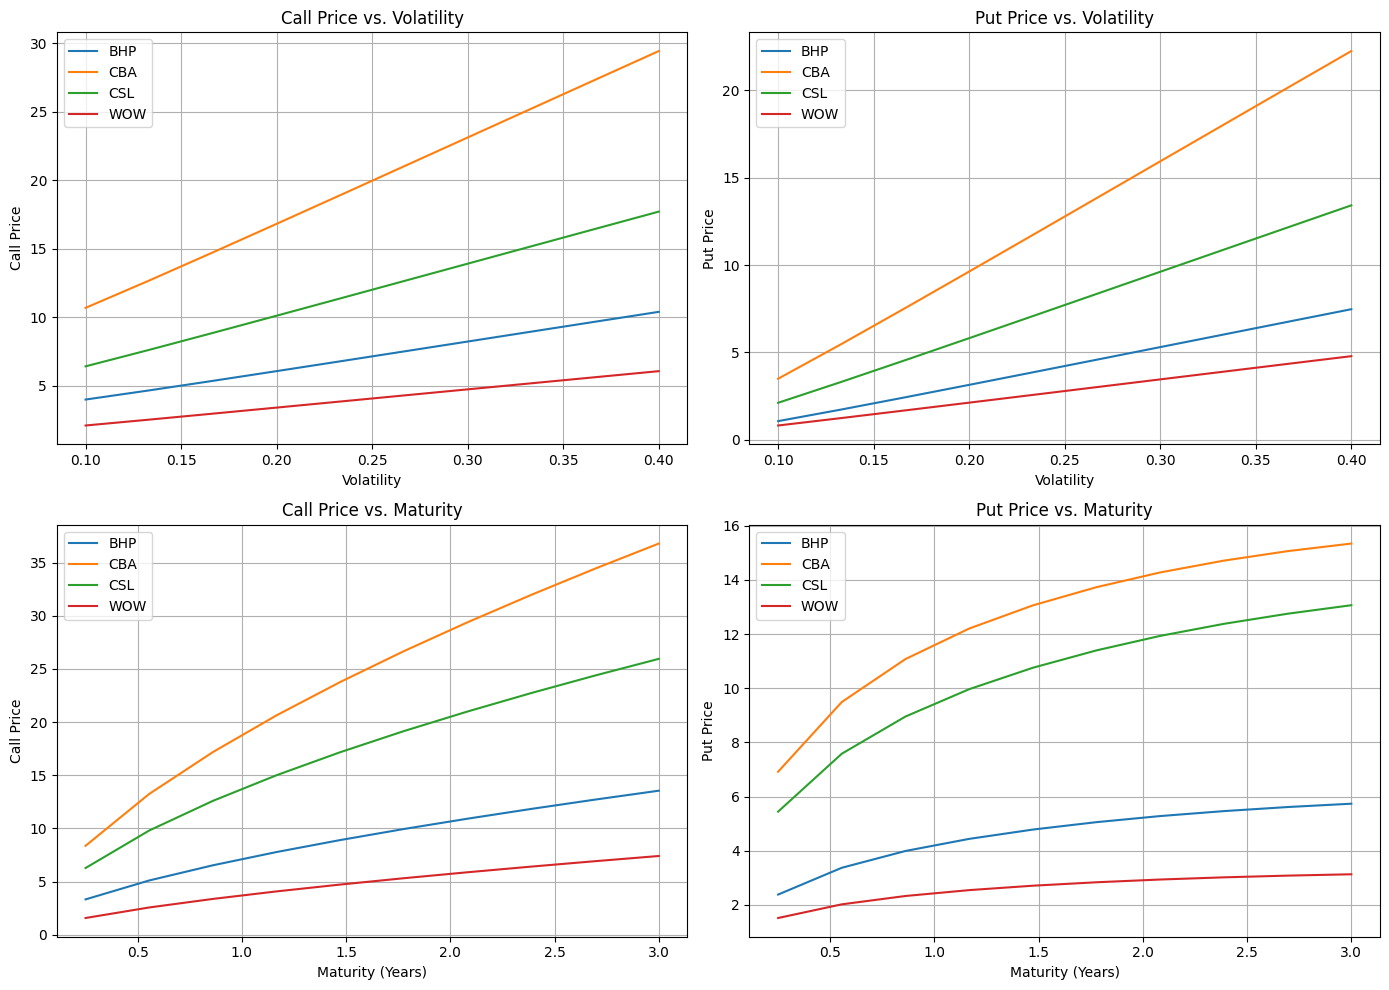

In [34]:
# Sense Checks — run for all equities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
vols = np.linspace(0.1, 0.4, 10)
maturities_range = np.linspace(0.25, 3.0, 10)

for name, params in equity_params.items():
    call_prices_v, put_prices_v = [], []
    for v in vols:
        call_prices_v.append(EuropeanCall(S0=params["S0"], K=params["K"],
                             T=T, sigma=v, yield_curve=curve).price())
        put_prices_v.append(EuropeanPut(S0=params["S0"], K=params["K"],
                            T=T, sigma=v, yield_curve=curve).price())

    call_prices_t, put_prices_t = [], []
    for t in maturities_range:
        call_prices_t.append(EuropeanCall(S0=params["S0"], K=params["K"],
                             T=t, sigma=params["sigma"], yield_curve=curve).price())
        put_prices_t.append(EuropeanPut(S0=params["S0"], K=params["K"],
                            T=t, sigma=params["sigma"], yield_curve=curve).price())

    axes[0, 0].plot(vols, call_prices_v, label=name)
    axes[0, 1].plot(vols, put_prices_v,  label=name)
    axes[1, 0].plot(maturities_range, call_prices_t, label=name)
    axes[1, 1].plot(maturities_range, put_prices_t,  label=name)

axes[0, 0].set_title("Call Price vs. Volatility")
axes[0, 0].set_xlabel("Volatility"); axes[0, 0].set_ylabel("Call Price")
axes[0, 0].legend(); axes[0, 0].grid(True)

axes[0, 1].set_title("Put Price vs. Volatility")
axes[0, 1].set_xlabel("Volatility"); axes[0, 1].set_ylabel("Put Price")
axes[0, 1].legend(); axes[0, 1].grid(True)

axes[1, 0].set_title("Call Price vs. Maturity")
axes[1, 0].set_xlabel("Maturity (Years)"); axes[1, 0].set_ylabel("Call Price")
axes[1, 0].legend(); axes[1, 0].grid(True)

axes[1, 1].set_title("Put Price vs. Maturity")
axes[1, 1].set_xlabel("Maturity (Years)"); axes[1, 1].set_ylabel("Put Price")
axes[1, 1].legend(); axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# 5.0 Conclusion

This notebook has demonstrated a fully functional risk and derivatives 
modelling platform built for an ASX equity portfolio, covering yield 
curve construction, derivative pricing, and portfolio risk analysis.

### Summary of Key Results

| Component | Output |
|---|---|
| Yield Curve | Upward sloping, 4.30% (3-month) to 5.04% (10-year) |
| Portfolio Value | $100,050.92 (equal dollar weighted, $100,000 total) |
| Portfolio Delta | 1,588.39 |
| Best Value Call | BHP @ $7.12 (24.92% vol) |
| Most Expensive Call | CBA @ $18.81 (23.17% vol, highest S0) |
| Historical VaR (95%, 1-day) | $1,444.58 (1.44% of portfolio) |
| Parametric VaR (95%, 1-day) | $1,491.55 (1.49% of portfolio) |
| Worst Case Scenario | Underlying -5%: P&L of -$5,129.02 (-5.13%) |

### Key Financial Findings

- Yield curve: The RBA yield curve is upward sloping in April 2026, 
consistent with a normalising rate environment where markets expect 
the cash rate to gradually decline from current elevated levels. 
The curve is used to provide market-consistent discount rates across 
all downstream pricing models.

- Option pricing: All European options are priced using Black-Scholes 
with yield-curve-implied risk-free rates. CSL has the highest volatility 
(29.54%) and therefore the highest relative option premium, while CBA 
has the highest absolute option prices due to its large spot price. 
American puts carry an early exercise premium of $0.18–$0.79 above 
their European equivalents. Asian calls are approximately 44–47% 
cheaper than European calls, consistent with the variance-reduction 
effect of price averaging.

- Portfolio risk: The portfolio is primarily equity-driven with 
a delta of 1,588, making it highly sensitive to equity price movements 
(±5% move ≈ ±$5,130 P&L) but almost entirely insensitive to interest 
rate shifts (±50bps ≈ ±$13 P&L). The consistency between historical 
and parametric VaR suggests the portfolio return distribution is 
approximately normal.

### Limitations 
- Constant Volatility: Relies on historical volatility, missing the dynamic volatility smile observed in live markets. 
- Single Underlying: The model assumes log-normal equity returns; multi-asset correlations not yet mapped
- Liquidity Risk: Does not account for bid-ask spreads in hedging costs.

### Extensions
- Dividend Adjustment: Extend Black-Scholes to incorporate continuous dividend yield for more accurate equity pricing. 
- Stochastic Volatility: Integration of the Heston Model to capture vol-of-vol dynamics. 
- GPU Acceleration: Moving Monte Carlo to CUDA for sub-millisecond pricing.


